# 06 — SDSS photo-z result audit

This notebook is a lightweight audit of the outputs produced by notebook 05. It replaces an older experimental deep-learning notebook that depended on undefined in-memory variables.

Run notebook 05 first, then use this notebook to check that the saved model-comparison tables tell a coherent story.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPORT = PROJECT_ROOT / 'report'
FIGURES = PROJECT_ROOT / 'figures'


## Load saved outputs

These files are generated by notebook 05 or `python run_photoz_analysis.py`.


In [2]:
required = {
    'metrics': REPORT / 'photoz_model_comparison.csv',
    'binned': REPORT / 'photoz_binned_residual_summary.csv',
    'sample': REPORT / 'photoz_sample_summary.csv',
    'uncertainty': REPORT / 'photoz_uncertainty_summary.csv',
}
missing = [name for name, path in required.items() if not path.exists()]
if missing:
    raise FileNotFoundError(f'Missing outputs from notebook 05: {missing}')

metrics = pd.read_csv(required['metrics'])
binned = pd.read_csv(required['binned'])
sample_summary = pd.read_csv(required['sample'])
uncertainty = pd.read_csv(required['uncertainty'])

sample_summary


,sample,n,z_min,z_median,z_max
0,raw_loaded,1000000,1.208629e-07,0.120447,0.309207
1,clean_after_quality_cuts,983821,1.000031e-02,0.120971,0.309207
2,modeling_stratified_max_50000,50000,1.006560e-02,0.120991,0.309200


## Main model ranking

For the report, rank models primarily by NMAD and outlier rate, not by R² alone. R² can look reassuring even when residuals have systematic structure.


In [3]:
ranked = metrics.sort_values('NMAD_dz_norm').reset_index(drop=True)
ranked[['model', 'NMAD_dz_norm', 'MAE_z', 'RMSE_z', 'outlier_rate_abs_dz_norm_gt_0p15', 'R2']]


,model,NMAD_dz_norm,MAE_z,RMSE_z,outlier_rate_abs_dz_norm_gt_0p15,R2
0,random_forest_classical,0.016342,0.017964,0.026541,0.00168,0.877492
1,mlp_ensemble_mean,0.016556,0.017972,0.026436,0.00136,0.878459
2,hist_gradient_boosting_classical,0.017027,0.018317,0.026710,0.00152,0.875933
3,knn_classical,0.017316,0.019037,0.027747,0.00144,0.866105
4,mlp_neural_network,0.017331,0.018832,0.028274,0.00200,0.860978
5,decision_tree_classical,0.018140,0.019954,0.029254,0.00192,0.851169
6,gradient_boosting_classical,0.018610,0.019733,0.028289,0.00160,0.860827
7,ridge_linear_baseline,0.027724,0.026804,0.036914,0.00248,0.763022
8,median_redshift_baseline,0.067556,0.061442,0.077357,0.00000,-0.040693


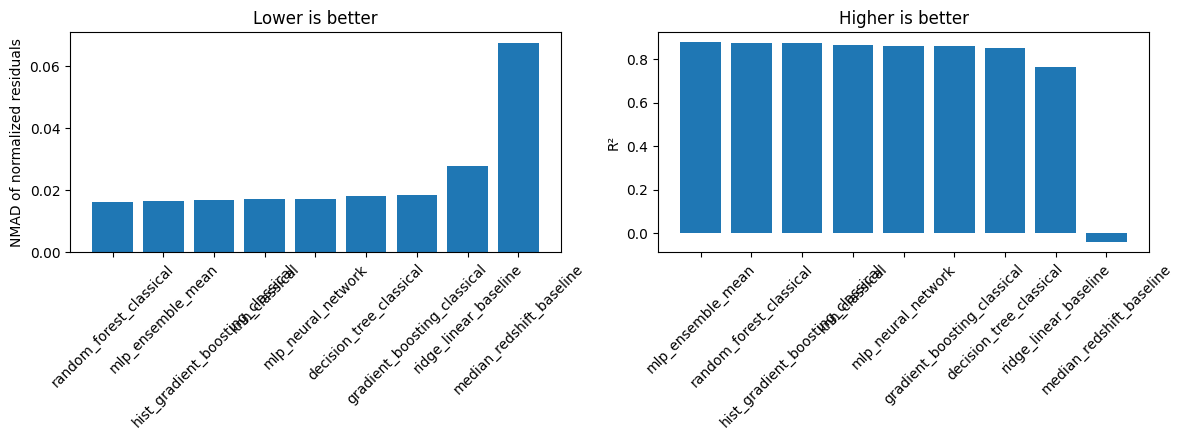

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ordered = ranked.copy()
axes[0].bar(ordered['model'], ordered['NMAD_dz_norm'])
axes[0].set_ylabel('NMAD of normalized residuals')
axes[0].set_title('Lower is better')
axes[0].tick_params(axis='x', rotation=45)

r2_ordered = metrics.sort_values('R2', ascending=False)
axes[1].bar(r2_ordered['model'], r2_ordered['R2'])
axes[1].set_ylabel('R²')
axes[1].set_title('Higher is better')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


## Redshift-bin dependence

This table checks whether the best average model is also stable as a function of redshift. A high-NMAD bin is a report-worthy limitation, not a failure of the project.


In [5]:
best_model = ranked.loc[0, 'model']
best_binned = binned[binned['model'] == best_model].copy()
best_binned.sort_values('z_bin')


,model,z_bin,n,median_dz_norm,mean_abs_dz_norm,nmad_dz_norm
28,random_forest_classical,"(-0.001, 0.1]",4849,0.007222,0.015449,0.014821
29,random_forest_classical,"(0.1, 0.2]",4960,-0.002337,0.015008,0.015855
30,random_forest_classical,"(0.2, 0.3]",2438,-0.003995,0.017208,0.017271
31,random_forest_classical,"(0.3, 0.4]",253,-0.016778,0.022975,0.012099


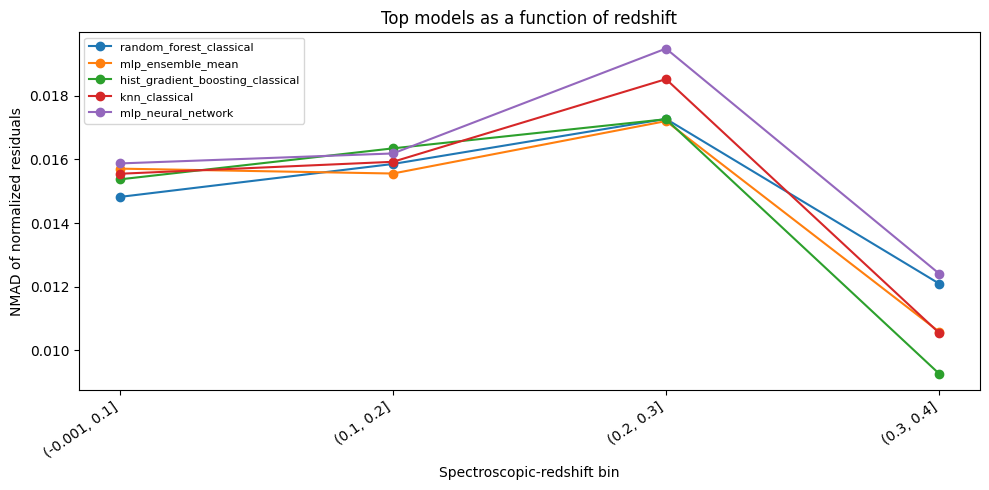

In [6]:
pivot = binned.pivot(index='z_bin', columns='model', values='nmad_dz_norm')
plt.figure(figsize=(10, 5))
for model in ranked['model'].head(5):
    if model in pivot.columns:
        plt.plot(range(len(pivot.index)), pivot[model], marker='o', label=model)
plt.xticks(range(len(pivot.index)), pivot.index, rotation=35, ha='right')
plt.ylabel('NMAD of normalized residuals')
plt.xlabel('Spectroscopic-redshift bin')
plt.title('Top models as a function of redshift')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


## Uncertainty proxy audit

The uncertainty proxies are useful only if their scatter correlates with absolute prediction error. The correlation does not need to be perfect, but a value near zero should be described honestly as weak calibration.


In [7]:
uncertainty


,method,mean_sigma,median_sigma,corr_abs_error_sigma
0,random_forest_tree_scatter,0.017265,0.015023,0.501690
1,mlp_ensemble_std,0.004909,0.003721,0.329539


## Audit conclusion

Use this notebook to write a short, concrete photo-z conclusion:

- state the cleaned and modelling sample sizes;
- identify the best model by NMAD;
- compare it with the median baseline;
- mention any redshift bins where performance worsens;
- describe uncertainty proxies as diagnostics, not calibrated error bars.
